# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [3]:
import torch

x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

# Calculate
mean = x.mean(dim=-1, keepdim=True)
variance = x.var(dim=-1, keepdim=True, unbiased=False)
normalized_output = (x - mean) / torch.sqrt(variance + 1e-5)

In [4]:
# Verify with
normalized_output.mean(dim=-1)
normalized_output.var(dim=-1, unbiased=False)

tensor([1.0000, 1.0000])

## Section 3: Exploring GELU
Compare ReLU and GELU

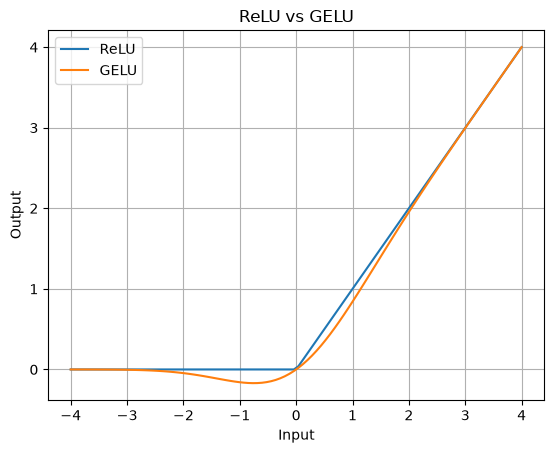

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Create input values from -4 to 4
x = torch.linspace(-4, 4, 100)

# Calculate ReLU and GELU
relu = F.relu(x)
gelu = F.gelu(x)

# Plot both
plt.plot(x, relu, label="ReLU")
plt.plot(x, gelu, label="GELU")

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("ReLU vs GELU")
plt.legend()
plt.grid()
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [7]:
import torch
import torch.nn as nn

# Create
x = torch.randn(2, 3, 768)

feed_forward = nn.Sequential(
    nn.Linear(768, 3072),
    nn.GELU(),
    nn.Linear(3072, 768)
)

In [8]:
# Pass through 
output = feed_forward(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)


Input shape: torch.Size([2, 3, 768])
Output shape: torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [10]:
import torch
import torch.nn as nn

# Create a toy input
x = torch.randn(2, 3, 768)

# Create a simple layer
layer = nn.Linear(768, 768)

# Without residual connection
output_without_residual = layer(x)

# With residual connection
output_with_residual = x + layer(x)

print("Input shape:", x.shape)
print("Without residual:", output_without_residual.shape)
print("With residual:", output_with_residual.shape)

Input shape: torch.Size([2, 3, 768])
Without residual: torch.Size([2, 3, 768])
With residual: torch.Size([2, 3, 768])


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output